<a href="https://colab.research.google.com/github/milan-jani/AI-Works/blob/main/Codes/Exp_3_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB-2: Classification using KNN, RF, MLP

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


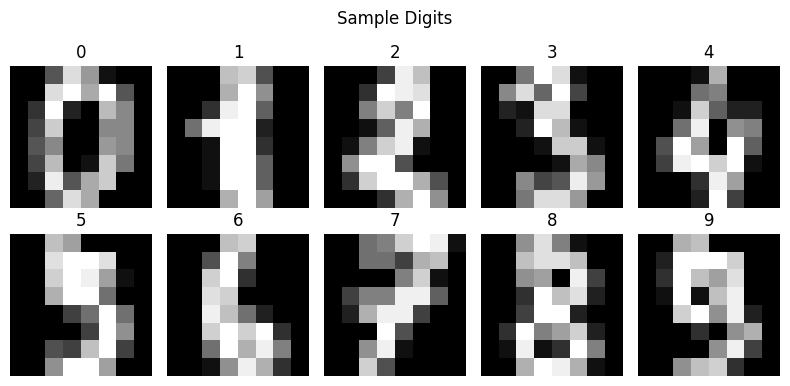

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"{y[i]}")
    plt.axis("off")
plt.suptitle("Sample Digits")
plt.tight_layout()
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 13, 15, 20]}

In [ ]:
rf_pipeline = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "rf__n_estimators": [25, 50, 100, 200, 500],
    "rf__max_depth": [None, 10, 20]}


In [ ]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ))
])

mlp_param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 64)],
    "mlp__activation": ["relu", "tanh"],
    #"mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001, 0.01, 1.0, 5.0, 10.0]
}


In [ ]:
#Training the model
def train_with_timing(pipeline, param_grid):
    start = time.time()
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    train_time = time.time() - start
    return grid, train_time

knn_grid, knn_train_time = train_with_timing(knn_pipeline, knn_param_grid)
rf_grid, rf_train_time = train_with_timing(rf_pipeline, rf_param_grid)
mlp_grid, mlp_train_time = train_with_timing(mlp_pipeline, mlp_param_grid)


In [ ]:
#Inferencing the model
def inference_time(model):
    start = time.time()
    model.predict(X_test)
    return time.time() - start

knn_test_time = inference_time(knn_grid.best_estimator_)
rf_test_time = inference_time(rf_grid.best_estimator_)
mlp_test_time = inference_time(mlp_grid.best_estimator_)

In [ ]:
#Evaluation
def evaluate_model(model):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    }

knn_metrics = evaluate_model(knn_grid.best_estimator_)
rf_metrics = evaluate_model(rf_grid.best_estimator_)
mlp_metrics = evaluate_model(mlp_grid.best_estimator_)

In [ ]:
#Result with comparison
results_df = pd.DataFrame(
    [knn_metrics, rf_metrics, mlp_metrics],
    index=["KNN", "Random Forest", "MLP"]
)

results_df["Training Time (s)"] = [
    knn_train_time, rf_train_time, mlp_train_time
]

results_df["Inference Time (s)"] = [
    knn_test_time, rf_test_time, mlp_test_time
]

print(results_df)

               Accuracy  Precision    Recall  F1-score  Training Time (s)  \
KNN            0.969444   0.969666  0.969444  0.969287           3.168355   
Random Forest  0.977778   0.978417  0.977778  0.977820          40.318762   
MLP            0.980556   0.980832  0.980556  0.980577          31.695325   

               Inference Time (s)  
KNN                      0.040209  
Random Forest            0.076912  
MLP                      0.016059  


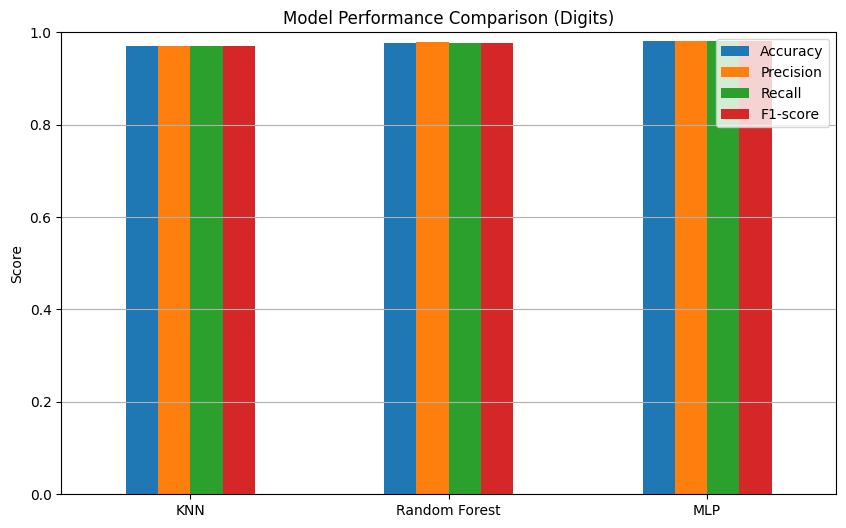

In [ ]:
results_df.iloc[:, :4].plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison (Digits)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

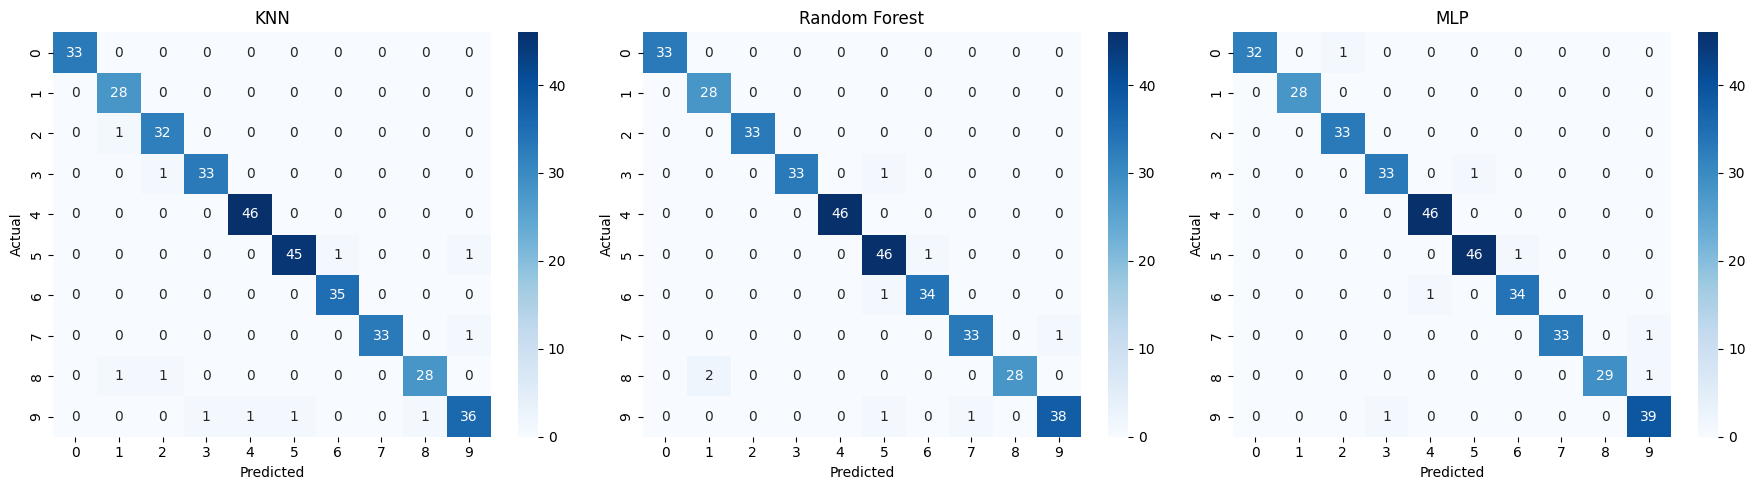

In [ ]:
models = {
    "KNN": knn_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "MLP": mlp_grid.best_estimator_
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Classification with Wine
 dataset**

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


In [ ]:


wine = load_wine()
X = wine.data
y = wine.target

print("Wine dataset loaded successfully. First 5 samples:")
print(X[:5])
print("First 5 target labels:")
print(y[:5])

Wine dataset loaded successfully. First 5 samples:
[[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
First 5 target labels:
[0 0 0 0 0]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 13, 15, 20]}

In [ ]:
rf_pipeline = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "rf__n_estimators": [25, 50, 100, 200, 500],
    "rf__max_depth": [None, 10, 20]}


In [ ]:
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ))
])

mlp_param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 64)],
    "mlp__activation": ["relu", "tanh"],
    #"mlp__alpha": [0.0001, 0.001],
    "mlp__learning_rate_init": [0.001, 0.01, 1.0, 5.0, 10.0]
}


In [ ]:
#Training the model
def train_with_timing(pipeline, param_grid):
    start = time.time()
    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    train_time = time.time() - start
    return grid, train_time

knn_grid, knn_train_time = train_with_timing(knn_pipeline, knn_param_grid)
rf_grid, rf_train_time = train_with_timing(rf_pipeline, rf_param_grid)
mlp_grid, mlp_train_time = train_with_timing(mlp_pipeline, mlp_param_grid)


In [ ]:
#Inferencing the model
def inference_time(model):
    start = time.time()
    model.predict(X_test)
    return time.time() - start

knn_test_time = inference_time(knn_grid.best_estimator_)
rf_test_time = inference_time(rf_grid.best_estimator_)
mlp_test_time = inference_time(mlp_grid.best_estimator_)

In [ ]:
#Evaluation
def evaluate_model(model):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    }

knn_metrics = evaluate_model(knn_grid.best_estimator_)
rf_metrics = evaluate_model(rf_grid.best_estimator_)
mlp_metrics = evaluate_model(mlp_grid.best_estimator_)

In [ ]:
#Result with comparison
results_df = pd.DataFrame(
    [knn_metrics, rf_metrics, mlp_metrics],
    index=["KNN", "Random Forest", "MLP"]
)

results_df["Training Time (s)"] = [
    knn_train_time, rf_train_time, mlp_train_time
]

results_df["Inference Time (s)"] = [
    knn_test_time, rf_test_time, mlp_test_time
]

print(results_df)

               Accuracy  Precision    Recall  F1-score  Training Time (s)  \
KNN            0.972222   0.974074  0.972222  0.972187           3.083125   
Random Forest  1.000000   1.000000  1.000000  1.000000          19.202439   
MLP            1.000000   1.000000  1.000000  1.000000           3.758281   

               Inference Time (s)  
KNN                      0.004150  
Random Forest            0.007587  
MLP                      0.000622  


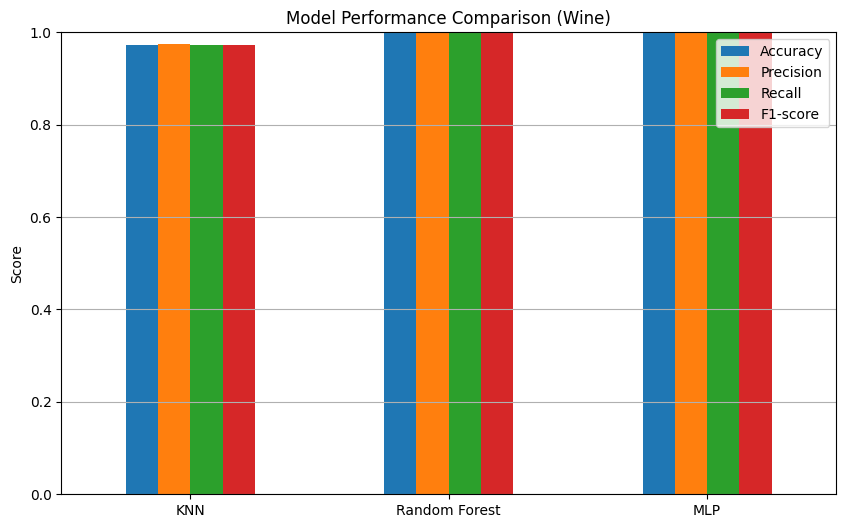

In [ ]:
results_df.iloc[:, :4].plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison (Wine)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

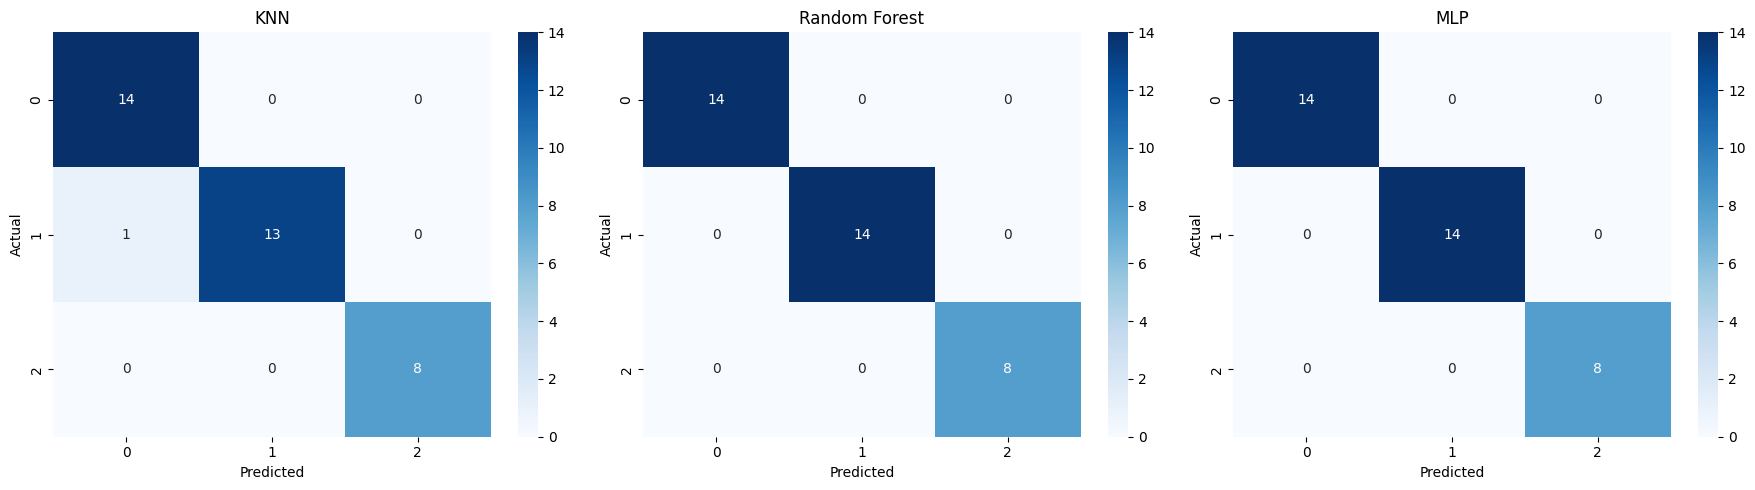

In [ ]:
models = {
    "KNN": knn_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "MLP": mlp_grid.best_estimator_
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()